# Stored restriction maps visualisations

## 1. Import an Functions

In [20]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats
from tkinter import font
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh

In [21]:
def fbc(L):
    l=L.shape[0]
    B=L.copy()
    for i in range(l):
        B[i,i]=np.sum(np.abs(L[i,:]))-np.abs(L[i,i])

    F=L-B
    return B , F

In [22]:
def matrix_abs(A):
    """
    Matrix absolute value: |A| = U Σ U^T, where A = U Σ V^T is the SVD.
    """
    U, S, Vt = np.linalg.svd(A)
    return U @ np.diag(S) @ U.T


def fbc_block(L, n, d):
    """
    Forman-Bochner decomposition for a block sheaf Laplacian (dense).
    Only suitable for small n — requires the full (n*d)x(n*d) matrix in RAM.
    """
    B = L.copy()
    for u in range(n):
        row_sum = np.zeros((d, d))
        for w in range(n):
            if w == u:
                continue
            block = L[u*d:(u+1)*d, w*d:(w+1)*d]
            if np.any(block != 0):
                row_sum += matrix_abs(block)
        B[u*d:(u+1)*d, u*d:(u+1)*d] = row_sum
    F = L - B
    return B, F


def compute_F_diags_from_coo(lap, n, d):
    """
    Compute F_{u,u} diagonal blocks of the Forman-Bochner decomposition
    directly from the COO-format sheaf Laplacian — no dense matrix needed.

    Background
    ----------
    The Forman-Bochner decomposition splits the sheaf Laplacian L into:
        L = B + F
    where B captures the "boundary" part (off-diagonal blocks unchanged,
    diagonal replaced by the sum of matrix-abs of neighbours) and F is the
    "curvature" remainder. Concretely, for each node u:

        B_{u,u} = sum_{v ~ u}  |L_{u,v}|       (matrix absolute value)
        F_{u,u} = L_{u,u}  -  B_{u,u}

    The eigenvalues of F_{u,u} are the per-node curvature scalars we care
    about. Crucially we only need these diagonal d×d blocks — the rest of
    F is never used — so we can skip building the full (n*d)×(n*d) matrix.

    Memory cost: O(E * d^2) vs O(n^2 * d^2) for the dense version.
    For roman_empire (n=22662, d=2) this means ~MB instead of ~15 GB.

    Parameters
    ----------
    lap : list/tuple of 3 tensors [row_indices, col_indices, values]
          COO representation of the (n*d) × (n*d) sheaf Laplacian,
          as saved by the training code.
    n   : number of graph nodes
    d   : stalk dimension (size of each block)

    Returns
    -------
    F_diags : np.ndarray of shape (n, d, d)
              F_{u,u} for every node u.
    """
    row_idx = lap[0].long().numpy().astype(np.int64)
    col_idx = lap[1].long().numpy().astype(np.int64)
    values  = lap[2].numpy()

    # The COO entries live in "scalar index" space (size n*d).
    # Convert each scalar index to (block_index, within-block offset):
    #   row i  →  block_row = i // d,  local_r = i % d
    # so the entry (row_idx[k], col_idx[k]) belongs to block (block_row[k], block_col[k])
    # at local position (local_r[k], local_c[k]) inside that d×d block.
    block_row = row_idx // d
    block_col = col_idx // d
    local_r   = row_idx % d
    local_c   = col_idx % d

    # Diagonal blocks are those where the block row equals the block column (u == v).
    is_diag = (block_row == block_col)

    # --- Step 1: collect diagonal blocks L_{u,u} ---
    # Scatter the COO values that belong to diagonal blocks into a (n, d, d) array.
    # np.add.at handles duplicate (u, r, c) indices correctly (accumulates).
    diag_blocks = np.zeros((n, d, d))
    dm = is_diag
    np.add.at(diag_blocks, (block_row[dm], local_r[dm], local_c[dm]), values[dm])

    # --- Step 2: group off-diagonal COO entries by their (u, v) block pair ---
    # We need one d×d matrix per (u,v) edge so we can apply matrix_abs to it.
    off_mask = ~is_diag
    off_br   = block_row[off_mask]   # source block (node u)
    off_bc   = block_col[off_mask]   # target block (node v)
    off_lr   = local_r[off_mask]     # row offset inside the d×d block
    off_lc   = local_c[off_mask]     # col offset inside the d×d block
    off_vals = values[off_mask]

    # Encode each (u, v) pair as a single integer so np.unique can find groups.
    # Since v < n always, the map  id = u*n + v  is injective.
    block_ids = off_br * n + off_bc
    unique_ids, inverse = np.unique(block_ids, return_inverse=True)
    # unique_ids : one entry per distinct (u,v) edge direction  (shape: num_blocks,)
    # inverse    : maps each COO entry back to its group index    (shape: len(off_vals),)
    num_blocks = len(unique_ids)

    # Scatter all off-diagonal scalar values into their respective d×d blocks.
    # After this, all_blocks[k] = L_{u_k, v_k}  for the k-th unique (u,v) pair.
    all_blocks = np.zeros((num_blocks, d, d))
    np.add.at(all_blocks, (inverse, off_lr, off_lc), off_vals)

    # --- Step 3: compute matrix_abs for all off-diagonal blocks in one batch SVD ---
    # matrix_abs(A) = U @ diag(S) @ U^T   (uses left singular vectors, not right)
    # We skip exact-zero blocks (isolated nodes / missing edges) to avoid SVD of zeros.
    nonzero_mask = np.any(all_blocks != 0, axis=(1, 2))
    abs_blocks = np.zeros_like(all_blocks)
    if np.any(nonzero_mask):
        nz = all_blocks[nonzero_mask]
        U, S, _ = np.linalg.svd(nz)                               # batch SVD
        # einsum: result[b,i,k] = sum_j  U[b,i,j] * S[b,j] * U[b,k,j]
        #                        = (U @ diag(S) @ U^T)[b]
        abs_blocks[nonzero_mask] = np.einsum('bij,bj,bkj->bik', U, S, U)

    # --- Step 4: accumulate B_{u,u} = sum_{v~u} |L_{u,v}| for every node u ---
    # Recover the source node u from the unique block id: u = id // n.
    B_diag = np.zeros((n, d, d))
    unique_block_rows = (unique_ids // n).astype(np.int64)
    # np.add.at accumulates all blocks that share the same source node u.
    np.add.at(B_diag, unique_block_rows, abs_blocks)

    # --- Step 5: F_{u,u} = L_{u,u} - B_{u,u} ---
    return diag_blocks - B_diag


def compute_entropic_C(D, exm, exM, n_t):
    # Computes the Von Neumann entropy and Entropic susceptibility of a given Laplacian
    # INPUTS
    # D: list of eigenvalues of the Laplacian matrix considered
    # exm, exM, n_t: computes the quantities in n_t logarithmically spaced time points
    #  in the interval [10**exm,10**exM] 

    # OUTPUTS
    # specific_heat: numpy array containing the entropic susceptibility values
    # tau_space: numpy array containing n_t - 1 logarithmically spaced time points
    # S: numpy array containing the Von Neumann entropy

    N = len(D)
    D = np.abs(D)
    tau_space = np.logspace(exm, exM, num=n_t)
    S = np.zeros(n_t)
    for t in range(n_t):
        tau = tau_space[t]
        mu = np.zeros(N)
        for i in range(N):
            mu[i] = 1 / np.sum(np.exp(-tau * (D - D[i])))

        mu = mu[mu > 0]
        S[t] = -np.sum(mu * np.log(mu))
    entropic_susceptibility = -(np.diff(S) / np.diff(np.log(tau_space)))
    tau_space = tau_space[: n_t - 1]
    return entropic_susceptibility, tau_space, S



def _lanczos_probes(L_sp, m, k, seed):
    """Run Lanczos once — reusable across all time steps."""
    rng = np.random.default_rng(seed)
    n = L_sp.shape[0]
    probes = []
    for _ in range(m):
        z = rng.choice([-1.0, 1.0], size=n).astype(np.float64)
        v = z / np.linalg.norm(z)
        alphas, betas = [], []
        v_prev = np.zeros(n)
        r = L_sp @ v
        a = float(v @ r); alphas.append(a); r -= a * v
        for _ in range(k - 1):
            b = float(np.linalg.norm(r))
            if b < 1e-12:
                break
            betas.append(b)
            v, v_prev = r / b, v
            r = L_sp @ v - b * v_prev
            a = float(v @ r); alphas.append(a); r -= a * v
        T = np.diag(alphas) + np.diag(betas, 1) + np.diag(betas, -1)
        theta, Q = np.linalg.eigh(T)
        probes.append((theta, Q[0, :] ** 2))
    return n, probes


def compute_entropic_C_slq(L_sp, exm, exM, n_t, m=60, k=150, seed=0):
    """
    Von Neumann entropy and entropic susceptibility via SLQ.
    No eigendecomposition — only sparse matvecs.
    """
    n, probes = _lanczos_probes(L_sp, m, k, seed)  # expensive step, done once
    tau_space = np.logspace(exm, exM, num=n_t)
    S = np.zeros(n_t)
    # analytical formula
    Z_sums = np.zeros(n_t)
    E_sums = np.zeros(n_t)
    for theta, w in probes:                    # ← just m iterations
        e = np.exp(-np.outer(tau_space, theta))  # (n_t, k)
        Z_sums += e @ w                          # (n_t,)
        E_sums += (e * theta[None, :]) @ w       # (n_t,)
    Z = n * Z_sums / m
    E = n * E_sums / m
    S = tau_space * (E / Z) + np.log(Z)

    C = -(np.diff(S) / np.diff(np.log(tau_space)))
    return C, tau_space[:n_t - 1], S


## 2. Data Manipulation: Load Laplacian and compute curvatures 

In [23]:
# Load maps and Laplacians
stalk_dim = 2
hidden_channels = 16
dataset = "citeseer"
layers = 4
epochs = 500
mode = "JointSheafParams"
model = "JointSheafParams"
Norm = "true"
learn_first_maps = True   # only affects filenames when mode == "JointSheafParamsAlt"
#num_nodes = 22662 # Roman Empire
#num_nodes = 10000 # minsesweeper
num_nodes = 3327 # Citeseer 
#num_nodes = 2708 # Cora
#num_nodes = 19717 # Pubmed
#num_nodes = 183 # Cornell
#num_nodes = 500 # synthetic
deg = 5
seed = 43
het_coef = 0.2
node_degree = 5
num_classes = 3
num_feats = 15

lfm_tag = f"_learn_first_maps-{str(learn_first_maps).lower()}" if mode == "JointSheafParamsAlt" else ""

#MAPS = []
LAPLACIANS = []
for layer in range(layers):
    #map_path = f"../results/maps/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/{mode}Sheaf_{dataset}_layer{layer}_fold3_seed43.pt"
    if dataset == "synthetic_exp":
        lap_path = f"../results/laplacians/normalised-{Norm}/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/{model}_nodes-{num_nodes}_node-deg-{node_degree}_layer{layer}_pct-hetero-{int(float(het_coef)*100)}_classes-{num_classes}_feats-{num_feats}{lfm_tag}_seed{seed}.pt"
    else: 
        #lap_path = f"../results/laplacians/normalised-{Norm}/{dataset}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/{mode}Sheaf_{dataset}_layer{layer}_fold3_seed43.pt"
        lap_path = f"../results/laplacians/{dataset}/normalised-{Norm}/stalk_dim-{stalk_dim}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/{model}_{dataset}_layer{layer}_fold0{lfm_tag}_seed{seed}.pt"
    #MAPS.append(torch.load(map_path))
    LAPLACIANS.append(torch.load(lap_path))

# Maps: shape [num_edges, 2 + d^2], first two cols are source/target
#d = stalk_dim
#map_cols = [f"a{i+1}{j+1}" for i in range(d) for j in range(d)]
#DF = []
#for maps_tensor in MAPS:
    #df = pd.DataFrame(maps_tensor[:, 2:].numpy(), columns=map_cols)
    #df.insert(0, "source", maps_tensor[:, 0].long().numpy())
    #df.insert(1, "target", maps_tensor[:, 1].long().numpy())
    #DF.append(df)

/tmp/ipykernel_1033791/1704123046.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  LAPLACIANS.append(torch.load(lap_path))


FileNotFoundError: [Errno 2] No such file or directory: '../results/laplacians/citeseer/normalised-true/stalk_dim-2/4-layers/16-hidden/500-epochs/JointSheafParams_citeseer_layer0_fold0_seed43.pt'

In [ ]:
from scipy.sparse.linalg import eigsh

n, d = num_nodes, stalk_dim

F_diag_list = []   # [layers] → (n, d, d)
e_list      = []   # [layers] → (k_eigs,)  partial eigenvalues of the full sheaf Laplacian
L_list = []
# Number of eigenvalues to compute — tune this up/down as needed
k_eigs = min(200, n * d - 2)
k_eigs = n*d - 2 
for lap in LAPLACIANS:
    row_idx = lap[0].long().numpy().astype(np.int64)
    col_idx = lap[1].long().numpy().astype(np.int64)
    values  = lap[2].numpy()

    # --- Forman-Bochner curvature (never builds dense matrix) ---
    F_diags = compute_F_diags_from_coo(lap, n, d)   # shape (n, d, d)
    F_diag_list.append(F_diags)

    # --- Sparse partial eigendecomposition of the full (n*d)x(n*d) Laplacian ---
    # Keep the Laplacian as a sparse CSR matrix — no .toarray() call
    #L_sp = sp.coo_matrix((values, (row_idx, col_idx)), shape=(n * d, n * d)).tocsr()
    #e, _ = eigsh(L_sp,k=k_eigs, which = 'SM')   # k smallest eigenvalues
    #e, _ = eigh(L_sp.todense())
    #e_list.append(np.sort(e))
    #L_list.append(L_sp)

curv_eigs = [np.linalg.eigvalsh(F_diag_list[layer]) for layer in range(layers)]  # [layers](n, d)


In [ ]:

lap = LAPLACIANS[0]
row_idx = lap[0].long().numpy()
col_idx = lap[1].long().numpy()

# Decode nd-space indices back to node numbers
edges = set()
for r, c in zip(row_idx, col_idx):
    u, v = int(r) // d, int(c) // d
    if u != v:
        edges.add((min(u, v), max(u, v)))

G = nx.Graph()
G.add_nodes_from(range(n))
G.add_edges_from(sorted(edges))
nodelist = list(range(n))
print(G.number_of_nodes(), G.number_of_edges())

# Keep the topological Laplacian sparse throughout
L_top_un = nx.laplacian_matrix(G, nodelist=nodelist).astype(float)   # sparse
degrees  = np.array(L_top_un.diagonal())
d0       = degrees + 1
D_inv_sqrt = sp.diags(1.0 / np.sqrt(d0))
L_top_sp = D_inv_sqrt @ L_top_un @ D_inv_sqrt   # sparse normalized Laplacian

# Scalar Forman curvature: f0[u] = 2*L[u,u] - sum_j |L[u,j]|
diag_vals    = np.array(L_top_sp.diagonal())
abs_row_sums = np.array(np.abs(L_top_sp).sum(axis=1)).ravel()
f0_top       = 2 * diag_vals - abs_row_sums

# Partial eigendecomposition (k smallest non-trivial) — avoids dense eigh
#k_eigs = min(200, n - 2)
#e_top, ev_top = eigsh(L_top_sp , k=k_eigs, which='SM')
#e_top, ev_top = eigh(L_top_sp.todense())
#e_top = np.sort(e_top)

3327 4552


## 3. Visualizations: Plot of curvatures, and then spectral quantities 

22662 22662 22662


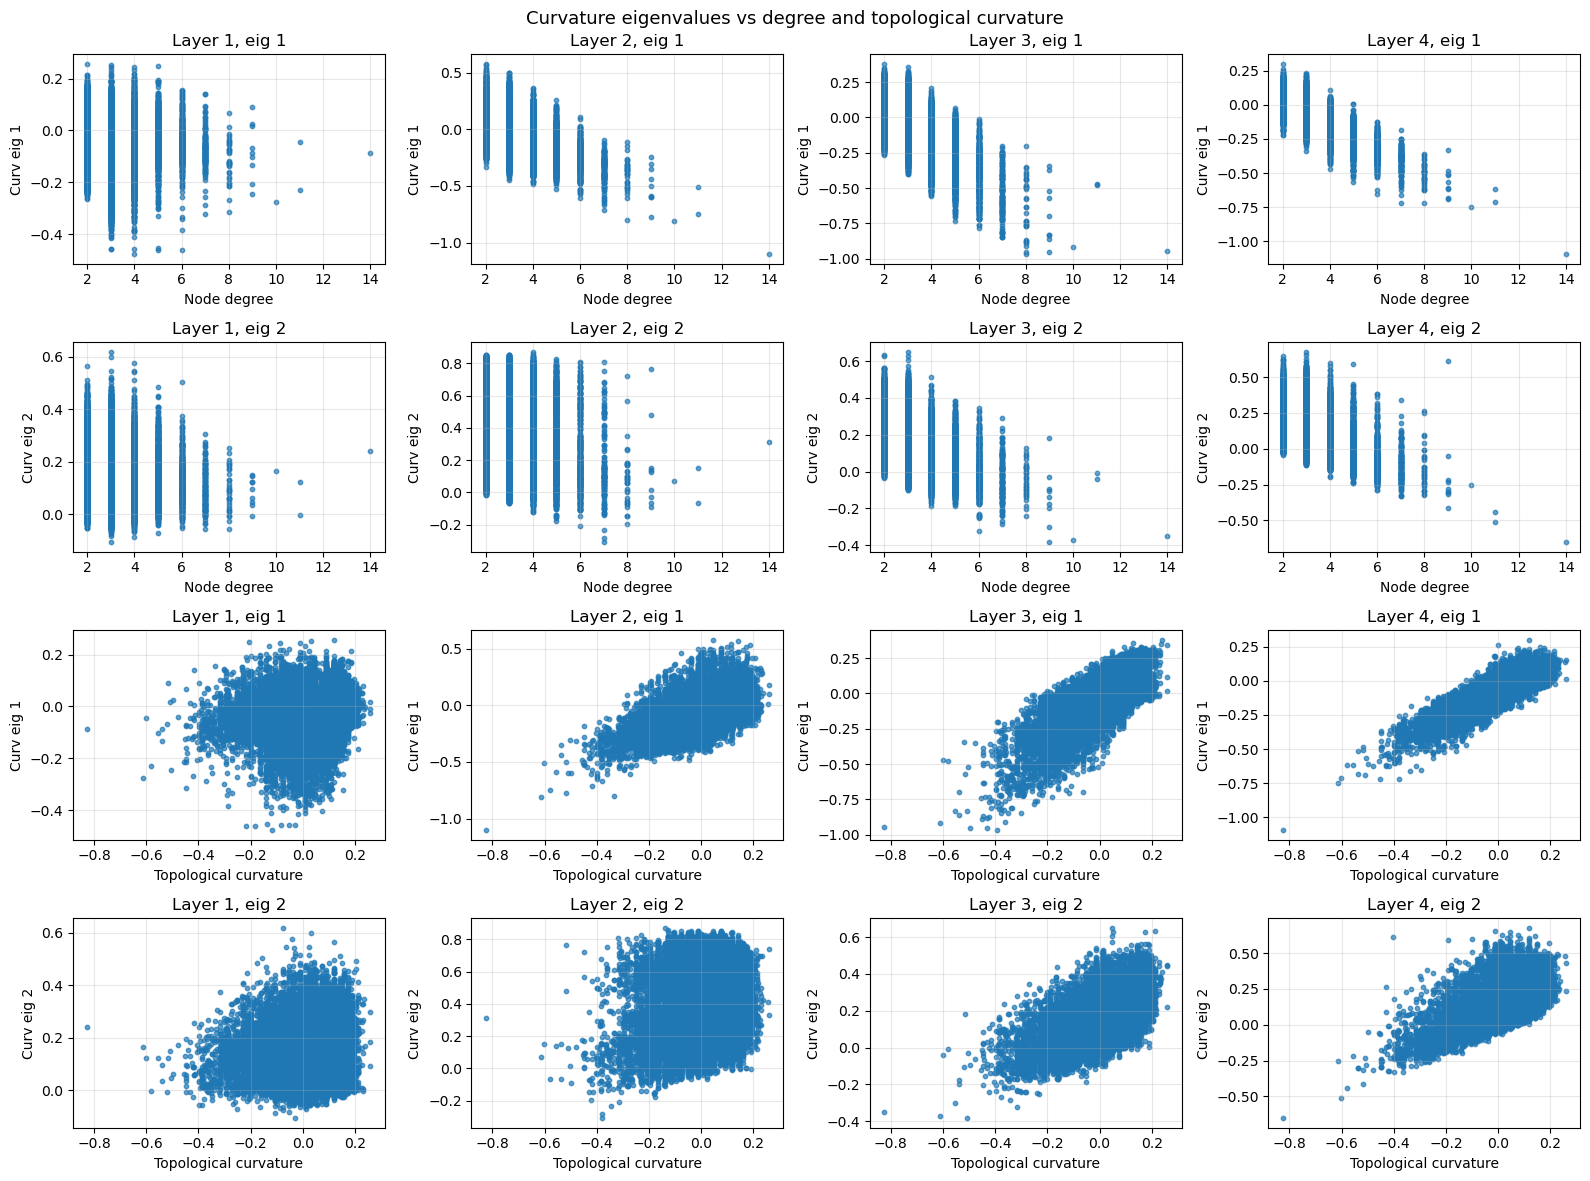

In [8]:
node_degrees = np.array([G.degree(u) for u in nodelist])
print(len(node_degrees), len(f0_top), len(curv_eigs[0][:,0]))
fig, axes = plt.subplots(2*d, layers, figsize=(4*layers, 3*2*d))
if layers == 1: axes = axes.reshape(-1, 1)

for k in range(d):
    for layer in range(layers):
        axes[k, layer].scatter(node_degrees, curv_eigs[layer][:, k], s=10, alpha=0.7)
        axes[k, layer].set_xlabel("Node degree")
        axes[k, layer].set_ylabel(f"Curv eig {k+1}")
        axes[k, layer].set_title(f"Layer {layer+1}, eig {k+1}")
        axes[k, layer].grid(alpha=0.3)

        axes[d+k, layer].scatter(f0_top, curv_eigs[layer][:, k], s=10, alpha=0.7)
        axes[d+k, layer].set_xlabel("Topological curvature")
        axes[d+k, layer].set_ylabel(f"Curv eig {k+1}")
        axes[d+k, layer].set_title(f"Layer {layer+1}, eig {k+1}")
        axes[d+k, layer].grid(alpha=0.3)

fig.suptitle("Curvature eigenvalues vs degree and topological curvature", fontsize=13)
fig.tight_layout()
fig.savefig(f"../results/images/{dataset}_mode_{mode}_layers_{layers}_Norm_{Norm}_d_{stalk_dim}_curv_scatter.pdf")

3327 3327 3327


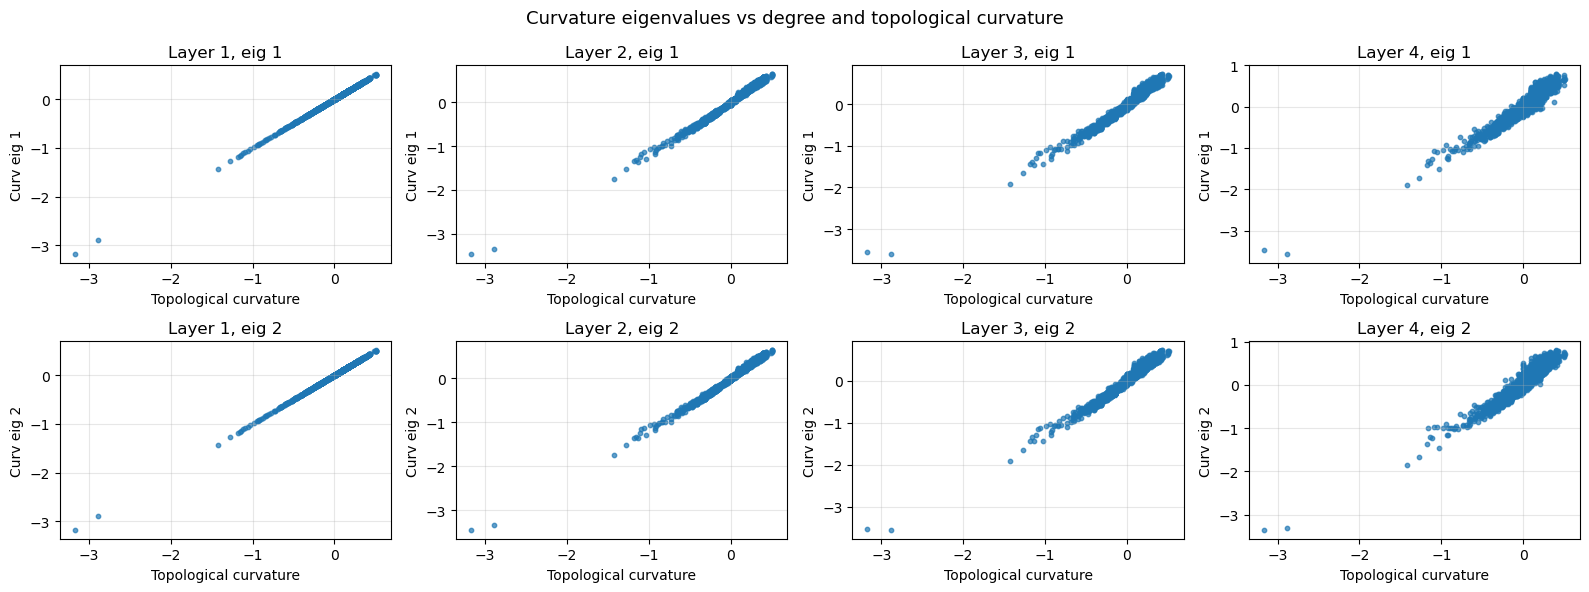

In [24]:
node_degrees = np.array([G.degree(u) for u in nodelist])
print(len(node_degrees), len(f0_top), len(curv_eigs[0][:,0]))
fig, axes = plt.subplots(d, layers, figsize=(4*layers, 3*d))
if layers == 1: axes = axes.reshape(-1, 1)

for k in range(d):
    for layer in range(layers):
        #axes[k, layer].scatter(node_degrees, curv_eigs[layer][:, k], s=10, alpha=0.7)
        #axes[k, layer].set_xlabel("Node degree")
        #axes[k, layer].set_ylabel(f"Curv eig {k+1}")
        #axes[k, layer].set_title(f"Layer {layer+1}, eig {k+1}")
        #axes[k, layer].grid(alpha=0.3)

        axes[k, layer].scatter(f0_top, curv_eigs[layer][:, k], s=10, alpha=0.7)
        axes[k, layer].set_xlabel("Topological curvature")
        axes[k, layer].set_ylabel(f"Curv eig {k+1}")
        axes[k, layer].set_title(f"Layer {layer+1}, eig {k+1}")
        axes[k, layer].grid(alpha=0.3)

fig.suptitle("Curvature eigenvalues vs degree and topological curvature", fontsize=13)
fig.tight_layout()
fig.savefig(f"../results/images/{dataset}_mode_{mode}_layers_{layers}_Norm_{Norm}_d_{stalk_dim}_curv_scatter_top_curv.pdf")

IndexError: list index out of range

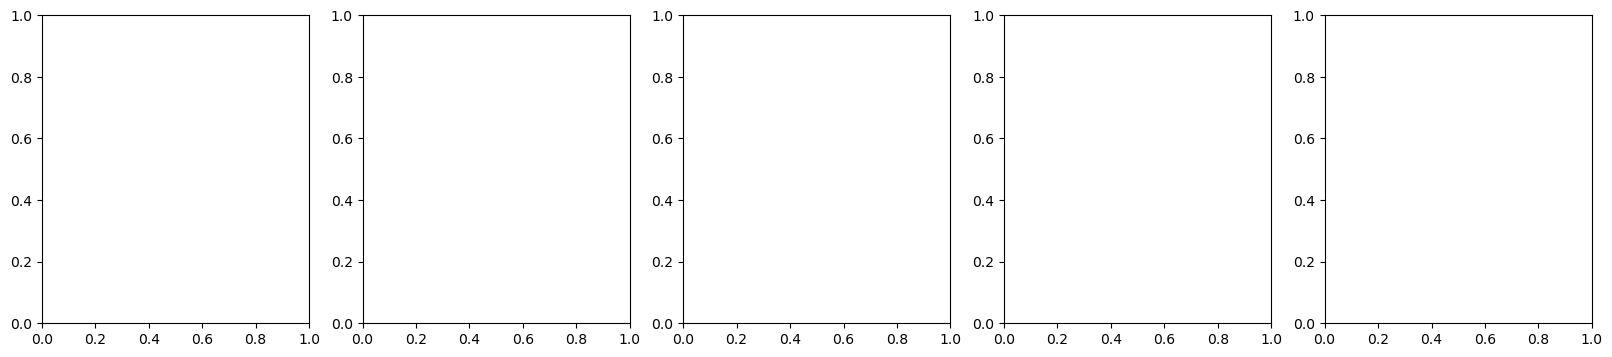

In [8]:
fig, axes = plt.subplots(1, layers+1, figsize=(4*(layers+1), 4))
for layer in range(layers):
    axes[layer].hist(e_list[layer], bins=30, edgecolor="black")
    axes[layer].axvline(0, color="red", linestyle="--")
    axes[layer].set_title(f"Sheaf Lap — Layer {layer+1}")
    axes[layer].set_xlabel("Eigenvalue")
    axes[layer].set_ylabel("Frequency")
    axes[layer].grid(alpha=0.3)
axes[layers].hist(e_top, bins=30, edgecolor="black")
axes[layers].axvline(0, color="red", linestyle="--")
axes[layers].set_title("Topological Laplacian")
axes[layers].set_xlabel("Eigenvalue")
axes[layers].grid(alpha=0.3)
fig.suptitle("Eigenvalue distributions", fontsize=13)
fig.tight_layout()
#fig.savefig(f"../results/images/{dataset}_mode_{mode}_layers_{layers}_Norm_{Norm}_d_{stalk_dim}_nodes-{num_nodes}_node-deg-{node_degree}_pct-hetero-{int(float(het_coef)*100)}_classes-{num_classes}_feats-{num_feats}_eig_distr.pdf")


In [180]:
# compute the entropic susceptibility per layer

# setting parameters for Entropic curves
#exm = -1 # C curve starts from 10**taumin
#exM = 8 # C curve ends at 10**taumax
#n_t = 1000 # Number of times to consider in the interval


#C_list_slq = []
#S_list_slq = []
#C_list = []
#S_list = []
#for layer in range(layers): 
    # computing entropic subsceptibility via SLQ
    #ce_slq,t_e_slq,se_slq=compute_entropic_C_slq(L_list[layer],exm,exM,n_t,m=500,k=500,seed=0)
    #C_list_slq.append(ce_slq)
    #S_list_slq.append(se_slq)
    #ce,t_e,se=compute_entropic_C(e_list[layer],exm,exM,n_t)
    #C_list.append(ce)
    #S_list.append(se)  


# computing entropic subsceptibility via SLQ
#ce_slq_0,t_e_slq_0,se_slq_0=compute_entropic_C_slq(L_top_sp,exm,exM,n_t,m=500,k=500,seed=0)
#ce_0,t_e_0,se_0=compute_entropic_C(e_top,exm,exM,n_t)

In [181]:
# compute the entropic susceptibility per layer

# setting parameters for Entropic curves
exm = -2 # C curve starts from 10**taumin
exM = 10 # C curve ends at 10**taumax
n_t = 1000 # Number of times to consider in the interval

C_list = []
S_list = []
for layer in range(layers): 
    ce,t_e,se=compute_entropic_C(e_list[layer],exm,exM,n_t)
    C_list.append(ce)
    S_list.append(se)  

ce_0,t_e_0,se_0=compute_entropic_C(e_top,exm,exM,n_t)

c:\Users\Utente\anaconda3\envs\Nuovo2_net\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Utente\AppData\Local\Temp\ipykernel_18400\35584449.py:153: RuntimeWarning: overflow encountered in exp
  mu[i] = 1 / np.sum(np.exp(-tau * (D - D[i])))


KeyboardInterrupt: 

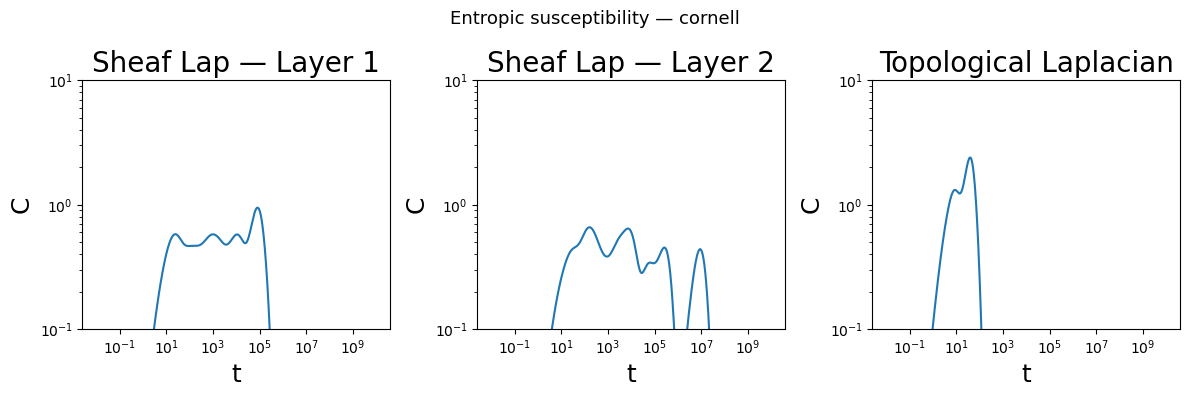

In [ ]:

fig, axes = plt.subplots(1, layers + 1, figsize=(4 * (layers + 1), 4))
axes = axes.flatten()
for layer in range(layers):
    axes[layer].loglog(t_e, C_list[layer])
    #axes[layer].loglog(t_e_slq, C_list_slq[layer])
    #axes[layer].legend(["True Entr. Susc.", "SLQ Approx."])
    axes[layer].set_ylabel("C", fontsize=18)
    axes[layer].set_xlabel("t", fontsize=18)
    axes[layer].set_ylim([pow(10, -1), 10])
    axes[layer].set_title(f"Sheaf Lap — Layer {layer + 1}", fontsize=20)
axes[layers].loglog(t_e_0, ce_0)
#axes[layers].loglog(t_e_0, ce_slq_0)
#axes[layer].legend(["True Entr. Susc.", "SLQ Approx."])
axes[layers].set_ylabel("C", fontsize=18)
axes[layers].set_xlabel("t", fontsize=18)
axes[layers].set_ylim([pow(10, -1), 10])
axes[layers].set_title("Topological Laplacian", fontsize=20)
fig.suptitle(f"Entropic susceptibility — {dataset}", fontsize=13)
plt.tight_layout()
#fig.savefig(f"../results/images/{dataset}_mode_{mode}_layers_{layers}_Norm_{Norm}_d_{stalk_dim}_nodes-{num_nodes}_node-deg-{node_degree}_pct-hetero-{int(float(het_coef)*100)}_classes-{num_classes}_feats-{num_feats}_susceptibility.pdf")


## 4. Plotting of the Graphs

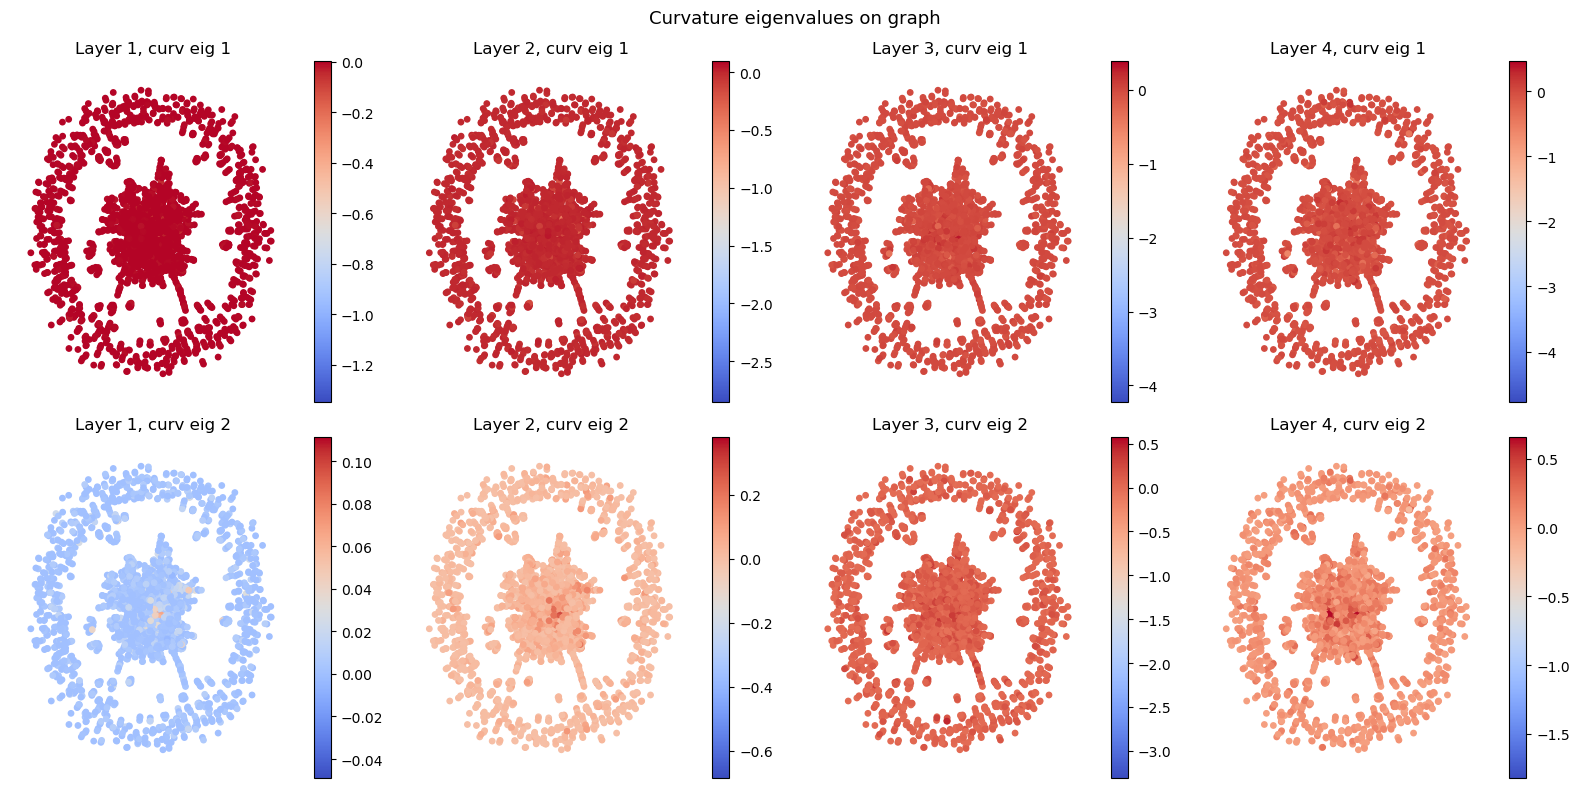

In [182]:
pos_use = nx.spring_layout(G, seed=42)
cmap = plt.cm.coolwarm

fig, axes = plt.subplots(d, layers, figsize=(4*layers, 4*d))
if d == 1: axes = axes.reshape(1, -1)
if layers == 1: axes = axes.reshape(-1, 1)

for k in range(d):
    for layer in range(layers):
        ax = axes[k, layer]
        vals = curv_eigs[layer][:, k]
        norm = plt.Normalize(vmin=vals.min(), vmax=vals.max())
        nx.draw_networkx_nodes(G, pos_use, ax=ax, nodelist=nodelist, node_size=15, node_color=cmap(norm(vals)))
        nx.draw_networkx_edges(G, pos_use, ax=ax, width=0.3, alpha=0.2)
        plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax)
        ax.set_title(f"Layer {layer+1}, curv eig {k+1}")
        ax.axis("off")

fig.suptitle("Curvature eigenvalues on graph", fontsize=13)
fig.tight_layout()
#fig.savefig(f"../results/images/{dataset}_curv_graph.pdf")


In [33]:
# Classify each node per layer as PSD / NSD / Indefinite
# based on the eigenvalues of its F_{u,u} curvature block
tol = 1e-8

node_types = []   # [layers] → (n,) array of strings
for layer in range(layers):
    eigs     = curv_eigs[layer]          # (n, d)
    has_pos  = np.any(eigs >  tol, axis=1)
    has_neg  = np.any(eigs < -tol, axis=1)
    types    = np.empty(n, dtype=object)
    types[has_pos & has_neg]   = 'indef'   # mixed signs → indefinite
    types[~has_neg]            = 'psd'     # all non-negative
    types[has_neg & ~has_pos]  = 'nsd'     # all non-positive
    node_types.append(types)

# Topological Laplacian: f0_top is scalar per node (d=1 case)
has_pos_top = f0_top >  tol
has_neg_top = f0_top < -tol
types_top   = np.empty(n, dtype=object)
types_top[has_pos_top & has_neg_top]  = 'indef'
types_top[~has_neg_top]               = 'psd'
types_top[has_neg_top & ~has_pos_top] = 'nsd'


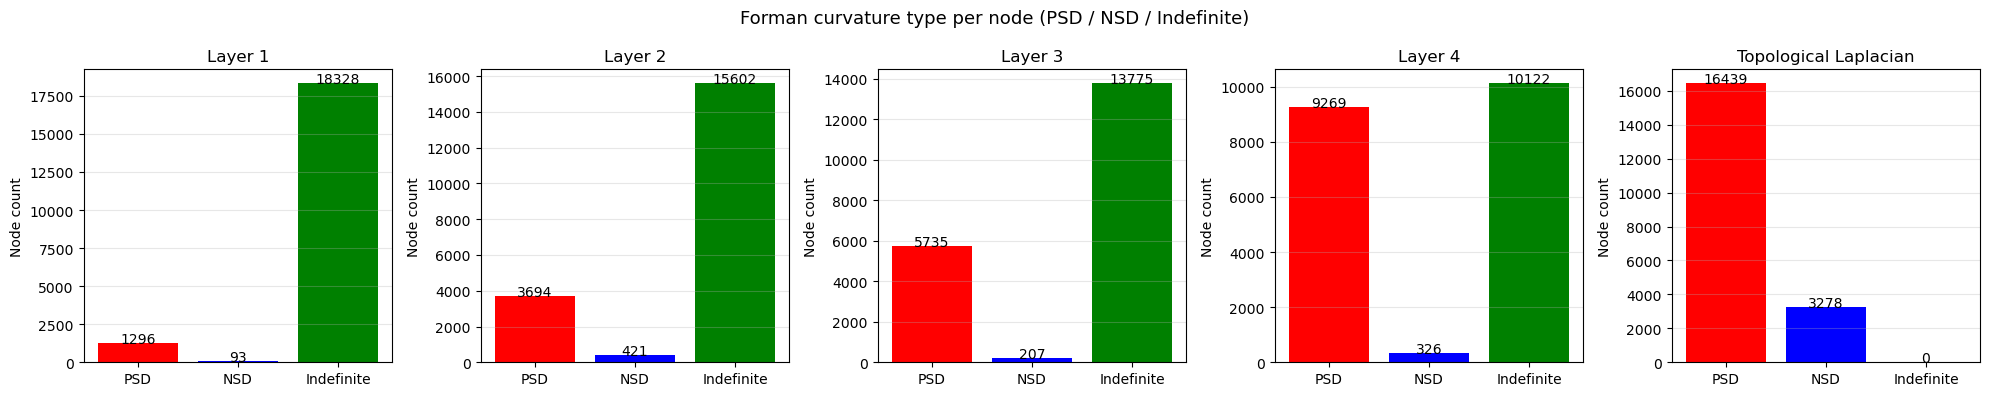

In [34]:
from matplotlib.patches import Patch

labels     = ['psd',  'nsd',  'indef']
bar_colors = ['red',  'blue', 'green']
bar_labels = ['PSD',  'NSD',  'Indefinite']

fig, axes = plt.subplots(1, layers + 1, figsize=(4 * (layers + 1), 4))
axes = axes.flatten()

for layer in range(layers):
    counts = [np.sum(node_types[layer] == t) for t in labels]
    bars = axes[layer].bar(bar_labels, counts, color=bar_colors)
    for bar, val in zip(bars, counts):
        axes[layer].text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 1, str(val),
                         ha='center', fontsize=10)
    axes[layer].set_title(f"Layer {layer + 1}")
    axes[layer].set_ylabel("Node count")
    axes[layer].grid(axis='y', alpha=0.3)

counts_top = [np.sum(types_top == t) for t in labels]
bars = axes[layers].bar(bar_labels, counts_top, color=bar_colors)
for bar, val in zip(bars, counts_top):
    axes[layers].text(bar.get_x() + bar.get_width() / 2,
                      bar.get_height() + 1, str(val),
                      ha='center', fontsize=10)
axes[layers].set_title("Topological Laplacian")
axes[layers].set_ylabel("Node count")
axes[layers].grid(axis='y', alpha=0.3)

fig.suptitle("Forman curvature type per node (PSD / NSD / Indefinite)", fontsize=13)
plt.tight_layout()
fig.savefig(f"../results/images/{dataset}_mode_{mode}_layers_{layers}_Norm_{Norm}_d_{stalk_dim}_curv_types_bar.pdf")


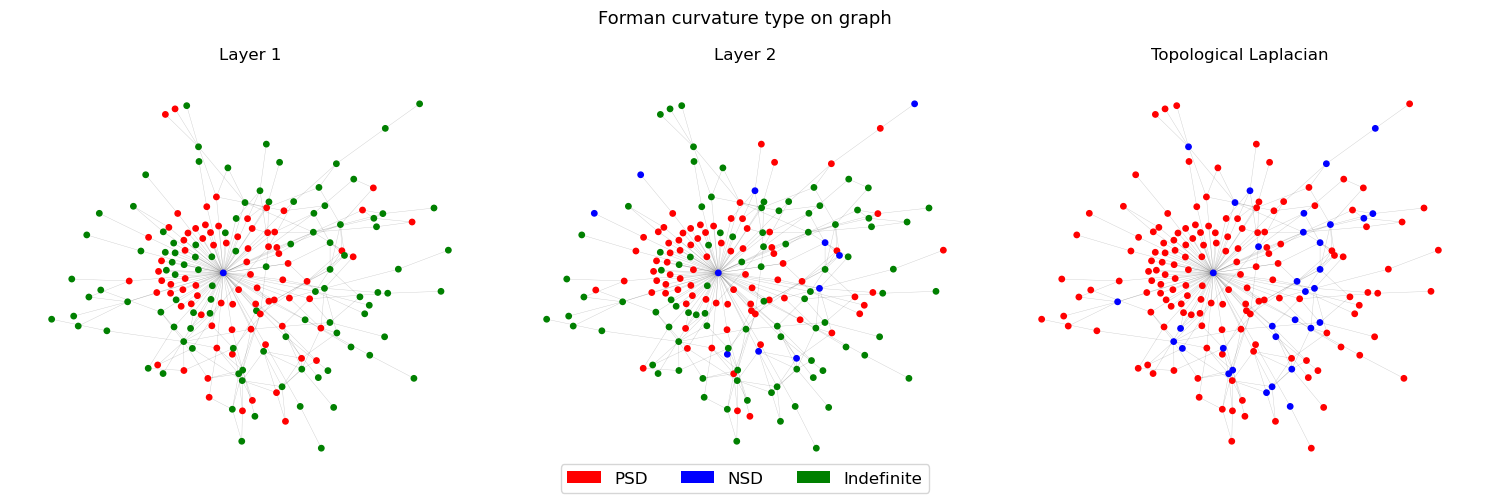

In [169]:
color_map = {'psd': 'red', 'nsd': 'blue', 'indef': 'green'}

legend_elements = [
    Patch(facecolor='red',   label='PSD'),
    Patch(facecolor='blue',  label='NSD'),
    Patch(facecolor='green', label='Indefinite'),
]

fig, axes = plt.subplots(1, layers + 1, figsize=(5 * (layers + 1), 5))
axes = axes.flatten()

for layer in range(layers):
    ax     = axes[layer]
    colors = [color_map[t] for t in node_types[layer]]
    nx.draw_networkx_nodes(G, pos_use, ax=ax, nodelist=nodelist,
                           node_size=15, node_color=colors)
    nx.draw_networkx_edges(G, pos_use, ax=ax, width=0.3, alpha=0.2)
    ax.set_title(f"Layer {layer + 1}")
    ax.axis("off")

colors_top = [color_map[t] for t in types_top]
nx.draw_networkx_nodes(G, pos_use, ax=axes[layers], nodelist=nodelist,
                       node_size=15, node_color=colors_top)
nx.draw_networkx_edges(G, pos_use, ax=axes[layers], width=0.3, alpha=0.2)
axes[layers].set_title("Topological Laplacian")
axes[layers].axis("off")

fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=12)
fig.suptitle("Forman curvature type on graph", fontsize=13)
plt.tight_layout()
fig.savefig(f"../results/images/{dataset}_mode_{mode}_layers_{layers}_Norm_{Norm}_d_{stalk_dim}_curv_types_graph.pdf")


# Analysis of the sign of the Laplacian (lying sheaves) d=1

In [ ]:
# Question, how many nodes are actually lying ?
# i.e. which entries of L_vu are positive ? (negative entries are "attractive", positive are "repulsive")
# so we test the ability of sheaves to lie,
# which is not captured by scalar Forman curvature 
# but should be reflected in the eigenvalues of the Laplacian.


In [ ]:
assert d == 1, "sign analysis is only meaningful for d=1 (scalar entries)"

for i, lap in enumerate(LAPLACIANS):
    row_idx  = lap[0].long().numpy()
    col_idx  = lap[1].long().numpy()
    values   = lap[2].numpy()

    # Upper-triangular off-diagonal: row < col (L is symmetric, avoids double counting)
    mask     = row_idx < col_idx
    off_vals = values[mask]
    total    = len(off_vals)

    n_pos  = int(np.sum(off_vals > 0))
    n_neg  = int(np.sum(off_vals < 0))
    n_zero = total - n_pos - n_neg

    print(f"Layer {i+1} — off-diagonal entries (upper triangular, total {total}):")
    print(f"  positive :  {n_pos:7d}  ({100 * n_pos  / total:.2f}%)")
    print(f"  negative :  {n_neg:7d}  ({100 * n_neg  / total:.2f}%)")
    #print(f"  zero     :  {n_zero:7d}  ({100 * n_zero / total:.2f}%)")

Layer 1 — off-diagonal entries (upper triangular, total 277):
  positive :        9  (3.25%)
  negative :      268  (96.75%)
  zero     :        0  (0.00%)
Layer 2 — off-diagonal entries (upper triangular, total 277):
  positive :      174  (62.82%)
  negative :      103  (37.18%)
  zero     :        0  (0.00%)


## 5. Node norm vs degree across layers

In [ ]:
# Load node norms
fold = 0

if dataset == "synthetic_exp":
    norms_path = (
        f"../results/node_norms/{dataset}/normalised-{Norm}/stalk_dim-{stalk_dim}/"
        f"{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/"
        f"{model}_nodes-{num_nodes}_node-deg-{node_degree}_"
        f"pct-hetero-{int(float(het_coef)*100)}_classes-{num_classes}_feats-{num_feats}{lfm_tag}_"
        f"fold{fold}_seed{seed}.pt"
    )
else:
    norms_path = (
        f"../results/node_norms/{dataset}/normalised-{Norm}/stalk_dim-{stalk_dim}/"
        f"{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/"
        f"{model}_{dataset}{lfm_tag}_fold{fold}_seed{seed}.pt"
    )

node_norms = torch.load(norms_path, weights_only=False)
# node_norms: dict {0: tensor([n]), 1: tensor([n]), ..., layers: tensor([n])}
# key t = X_t (input to layer t); key layers = X_L (final output)

node_degrees = np.array([G.degree(u) for u in nodelist])

# Betweenness centrality — use k<n for a fast approximation on large graphs
# (exact computation is O(VE), can be slow for n > 5000)
k_approx = min(1000, G.number_of_nodes())
betweenness = nx.betweenness_centrality(G, k=k_approx, seed=42)
node_betweenness = np.array([betweenness[u] for u in nodelist])

num_snapshots = layers + 1  # X_0 ... X_L
fig, axes = plt.subplots(2, num_snapshots, figsize=(4 * num_snapshots, 8))
if num_snapshots == 1:
    axes = axes.reshape(2, 1)

for t in range(num_snapshots):
    norms_t = node_norms[t].numpy()
    if t == 0:
        title = "X_0 (input)"
    elif t == layers:
        title = f"X_{layers} (final)"
    else:
        title = f"X_{t} (after layer {t})"

    # Row 0: norm vs degree
    axes[0, t].scatter(node_degrees, norms_t, s=10, alpha=0.7)
    axes[0, t].set_xlabel("Node degree")
    axes[0, t].set_ylabel("Node norm")
    axes[0, t].set_title(title)
    axes[0, t].grid(alpha=0.3)

    # Row 1: norm vs betweenness centrality
    axes[1, t].scatter(node_betweenness, norms_t, s=10, alpha=0.7)
    axes[1, t].set_xlabel("Betweenness centrality")
    axes[1, t].set_ylabel("Node norm")
    axes[1, t].set_title(title)
    axes[1, t].grid(alpha=0.3)

fig.suptitle(f"Node norm vs degree / betweenness — {dataset}, {model}, stalk_dim={stalk_dim}", fontsize=13)
fig.tight_layout()
fig.savefig(
    f"../results/images/{dataset}_mode_{mode}_layers_{layers}_Norm_{Norm}_d_{stalk_dim}{lfm_tag}_norm_vs_degree_betweenness.pdf"
)